Dataset shape: (2930, 82)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str  

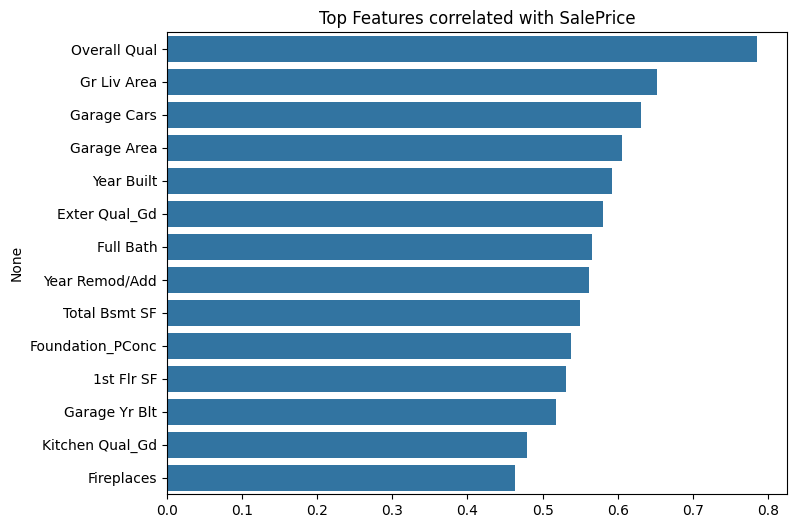


Final dataset shape: (2793, 228)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ======================
# 1. LOAD DATA
# determinar el precio de venta de una casa en función de sus características
# ======================
df = pd.read_csv("dataset_p1/1amesHhousingDataset/AmesHousing.csv")

print("Dataset shape:", df.shape)
print("\nInfo:")
df.info()

# ======================
# 2. MISSING VALUES
# ======================
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("\nMissing values:")
print(missing)

# ======================
# 3. DROP COLUMNS WITH TOO MANY NaN
# ======================
threshold = 0.4  # elimina columnas con más del 40% de NaN
df = df.loc[:, df.isnull().mean() < threshold]

# ======================
# 4. IMPUTATION (MODERNA)
# ======================
df = df.convert_dtypes()
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include=['object', 'string']).columns

# Numéricas → mediana
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categóricas → "Missing" (mejor que moda en muchos casos)
df[cat_cols] = df[cat_cols].fillna("Missing")

# ======================
# 5. ENCODING (CONTROLADO)
# ======================
# Limitar cardinalidad (evita explosión)
for col in cat_cols:
    if df[col].nunique() > 20:
        df[col] = "Other"

df_encoded = pd.get_dummies(df, drop_first=True)

# ======================
# 6. OUTLIERS (ROBUSTO)
# ======================
def remove_outliers_iqr(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    
    return df

df_encoded = remove_outliers_iqr(df_encoded, ["SalePrice"])

# ======================
# 7. CORRELATION (ÚTIL)
# ======================
# Solo top correlaciones con target
corr = df_encoded.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)

top_features = corr[1:15]  # top 15

plt.figure(figsize=(8,6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Top Features correlated with SalePrice")
plt.show()

# ======================
# 8. FINAL
# ======================
print("\nFinal dataset shape:", df_encoded.shape)